# 🚢 TP Complet — Data Science & Machine Learning (Titanic)

---

**Objectifs :**
- Étude exploratoire des données (EDA)
- Data visualisation
- Modélisation (minimum 8 modèles)
- Analyse du sur-apprentissage
- Optimisation (Grid Search CV)
- Ensemble Learning
- Introduction au MLOps

---

## ⚙️ Imports & Configuration

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

# Ajouter le répertoire parent au path
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Nos modules personnalisés
from src.preprocessing import (
    load_data, show_missing, extract_title, impute_age,
    impute_embarked, impute_fare, create_features,
    encode_features, drop_useless_columns,
    full_preprocessing, prepare_train_test
)
from src.models import get_all_models, get_param_grids, get_ensemble_models
from src.evaluate import (
    train_and_evaluate, compare_models, cross_validate_models,
    plot_model_comparison, plot_overfitting, plot_confusion_matrix,
    plot_roc_curves, plot_feature_importance, plot_learning_curve,
    plot_survival_overview, plot_correlation_heatmap,
    save_best_model
)

# Style
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("✅ Tous les imports sont OK !")

✅ Tous les imports sont OK !


---
# 📊 Partie 1 — Exploration des Données

**Objectifs :**
- Comprendre les variables
- Identifier la variable cible
- Analyse univariée et bivariée

In [2]:
# Chargement du dataset
df = load_data("../data/train.csv")

✅ Dataset chargé : 891 lignes × 12 colonnes
   Colonnes : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [3]:
# Aperçu des premières lignes
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
# Informations sur le dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# Statistiques descriptives
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [6]:
# Variable cible : Survived
print("=" * 50)
print("VARIABLE CIBLE : Survived")
print("=" * 50)
print(f"\n0 = Décédé, 1 = Survécu")
print(f"\nDistribution :")
print(df["Survived"].value_counts())
print(f"\nTaux de survie : {df['Survived'].mean():.1%}")

VARIABLE CIBLE : Survived

0 = Décédé, 1 = Survécu

Distribution :
Survived
0    549
1    342
Name: count, dtype: int64

Taux de survie : 38.4%


In [7]:
# Valeurs manquantes
show_missing(df)


📊 Valeurs manquantes :
          Manquantes  Pourcentage (%)
Cabin            687            77.10
Age              177            19.87
Embarked           2             0.22


,Manquantes,Pourcentage (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


### Analyse Bivariée

In [8]:
# Survie par sexe
print("\n📊 Survie par Sexe :")
print(df.groupby("Sex")["Survived"].agg(["count", "sum", "mean"]).round(3))
print(f"\n→ Les femmes ont {df[df['Sex']=='female']['Survived'].mean()/df[df['Sex']=='male']['Survived'].mean():.1f}x plus de chances de survivre")


📊 Survie par Sexe :
        count  sum   mean
Sex                      
female    314  233  0.742
male      577  109  0.189

→ Les femmes ont 3.9x plus de chances de survivre


In [9]:
# Survie par classe
print("\n📊 Survie par Classe :")
print(df.groupby("Pclass")["Survived"].agg(["count", "sum", "mean"]).round(3))


📊 Survie par Classe :
        count  sum   mean
Pclass                   
1         216  136  0.630
2         184   87  0.473
3         491  119  0.242


In [10]:
# Survie croisée Sexe × Classe
print("\n📊 Survie par Sexe × Classe :")
print(df.groupby(["Sex", "Pclass"])["Survived"].agg(["count", "sum", "mean"]).round(3))


📊 Survie par Sexe × Classe :
               count  sum   mean
Sex    Pclass                   
female 1          94   91  0.968
       2          76   70  0.921
       3         144   72  0.500
male   1         122   45  0.369
       2         108   17  0.157
       3         347   47  0.135


In [11]:
# Survie par port d'embarquement
print("\n📊 Survie par Port :")
print(df.groupby("Embarked")["Survived"].agg(["count", "sum", "mean"]).round(3))


📊 Survie par Port :
          count  sum   mean
Embarked                   
C           168   93  0.554
Q            77   30  0.390
S           644  217  0.337


In [12]:
# Corrélation avec la survie
print("\n📊 Corrélation avec Survived :")
numeric_cols = df.select_dtypes(include="number").columns
print(df[numeric_cols].corr()["Survived"].sort_values(ascending=False).round(3))


📊 Corrélation avec Survived :
Survived       1.000
Fare           0.257
Parch          0.082
PassengerId   -0.005
SibSp         -0.035
Age           -0.077
Pclass        -0.338
Name: Survived, dtype: float64


---
# 📈 Partie 2 — Data Visualisation

**Objectifs :**
- Histogrammes
- Diagrammes en barres
- Boxplots
- Heatmap de corrélation

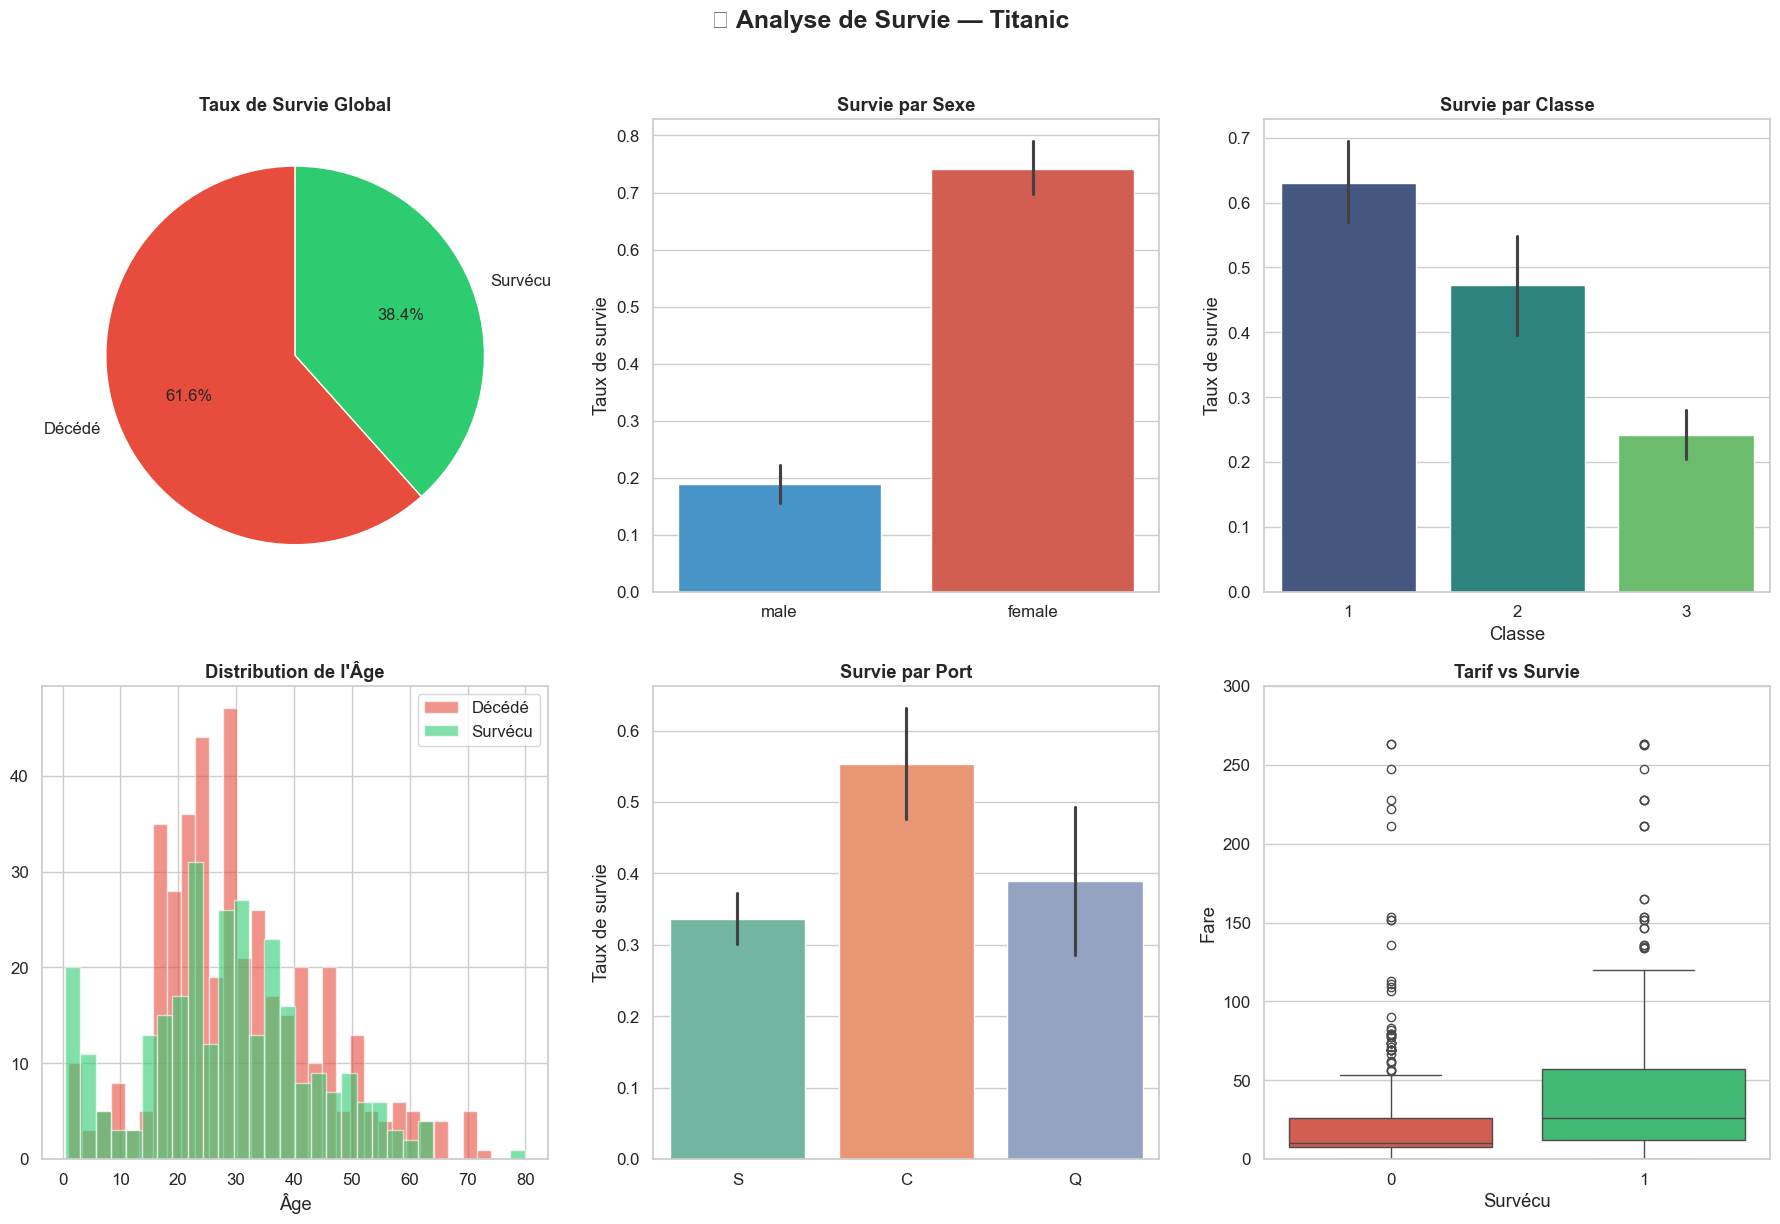

In [13]:
# Dashboard complet EDA
plot_survival_overview(df)

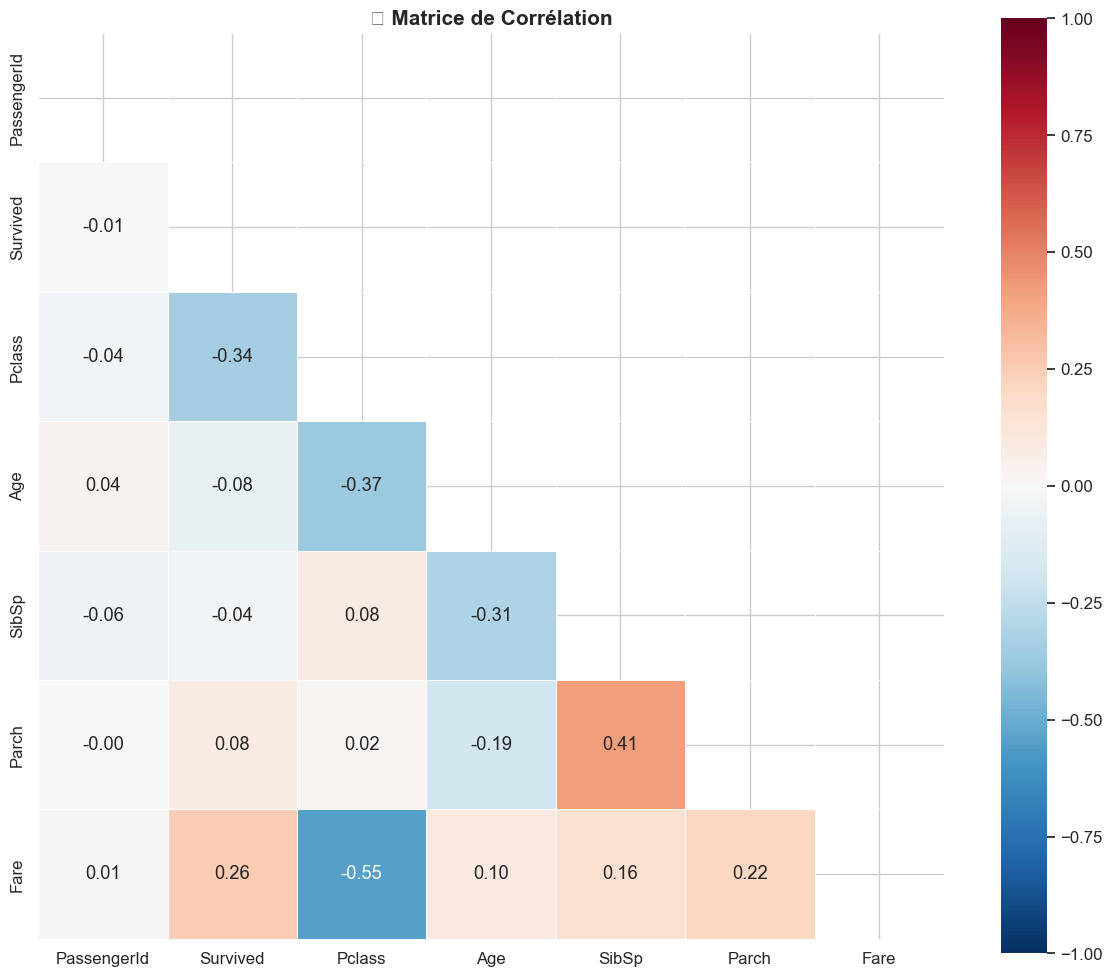

In [14]:
# Heatmap de corrélation
plot_correlation_heatmap(df)

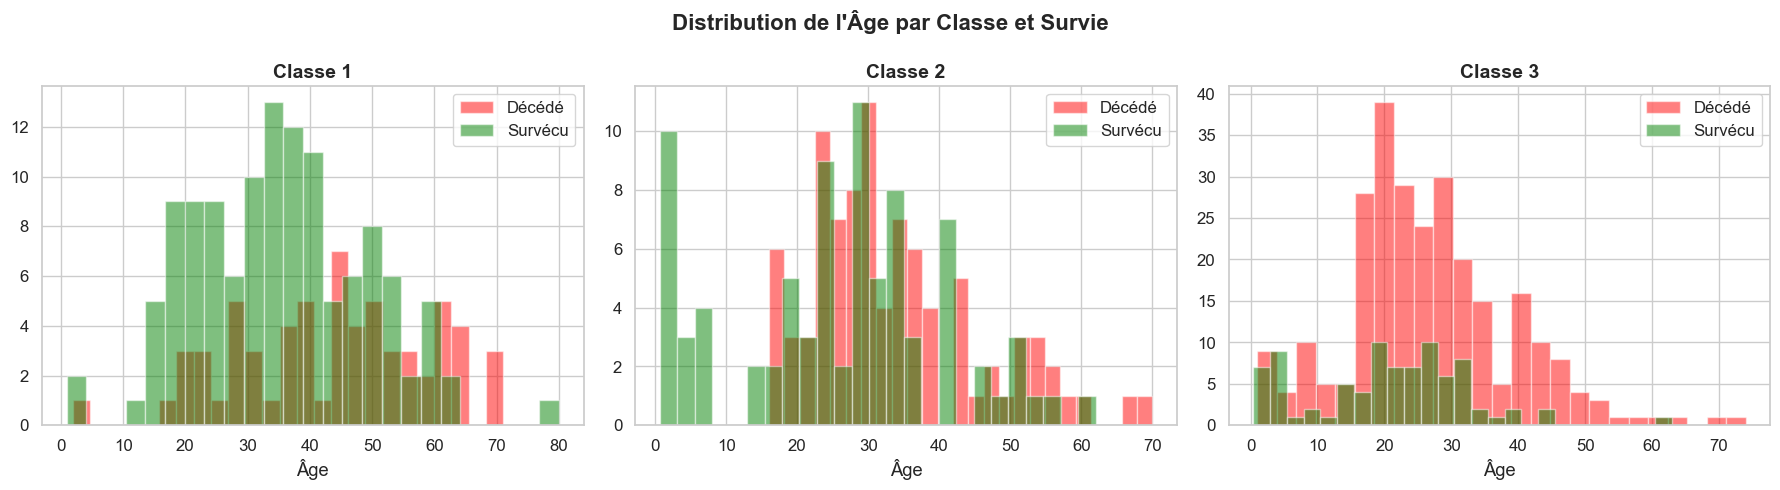

In [15]:
# Distribution de l'âge par classe et survie
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, pclass in enumerate([1, 2, 3]):
    ax = axes[i]
    subset = df[df["Pclass"] == pclass]
    subset[subset["Survived"] == 0]["Age"].hist(bins=25, alpha=0.5, color="red", label="Décédé", ax=ax)
    subset[subset["Survived"] == 1]["Age"].hist(bins=25, alpha=0.5, color="green", label="Survécu", ax=ax)
    ax.set_title(f"Classe {pclass}", fontweight="bold", fontsize=14)
    ax.set_xlabel("Âge")
    ax.legend()
fig.suptitle("Distribution de l'Âge par Classe et Survie", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

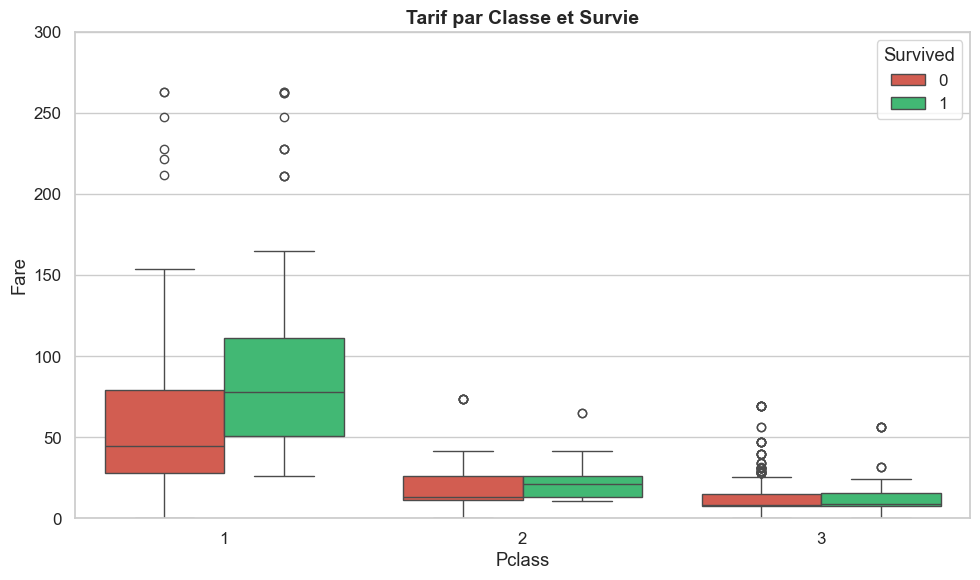

In [16]:
# Tarif par classe (boxplot)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="Pclass", y="Fare", hue="Survived", palette=["#e74c3c", "#2ecc71"], ax=ax)
ax.set_title("Tarif par Classe et Survie", fontsize=14, fontweight="bold")
ax.set_ylim(0, 300)
plt.tight_layout()
plt.show()

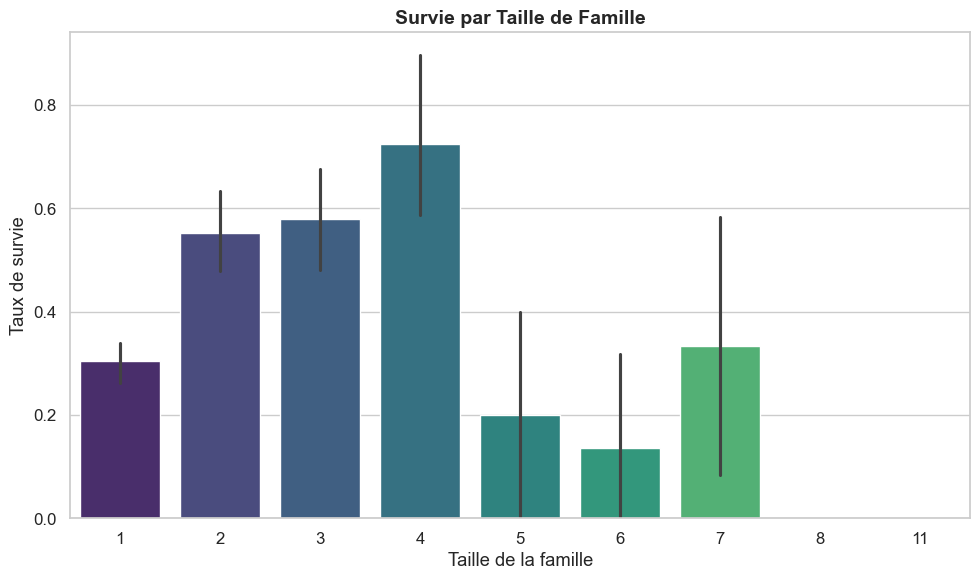

In [17]:
# Taille de la famille et survie
df_temp = df.copy()
df_temp["FamilySize"] = df_temp["SibSp"] + df_temp["Parch"] + 1

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_temp, x="FamilySize", y="Survived", palette="viridis", ax=ax)
ax.set_title("Survie par Taille de Famille", fontsize=14, fontweight="bold")
ax.set_xlabel("Taille de la famille")
ax.set_ylabel("Taux de survie")
plt.tight_layout()
plt.show()

---
# 🔧 Partie 3 — Préparation des Données

**Objectifs :**
- Gestion des valeurs manquantes
- Encodage des variables catégorielles
- Feature engineering
- Normalisation

In [18]:
# Recharger les données propres
df = load_data("../data/train.csv")

# Pipeline complète de preprocessing
df_clean = full_preprocessing(df)

✅ Dataset chargé : 891 lignes × 12 colonnes
   Colonnes : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

🔧 PIPELINE DE PREPROCESSING
✅ Titres extraits : {'Mr': np.int64(517), 'Miss': np.int64(185), 'Mrs': np.int64(126), 'Master': np.int64(40), 'Rare': np.int64(23)}
✅ Age imputé : 177 valeurs manquantes → 0
✅ Embarked imputé : 2 valeurs → mode 'S'
✅ Features créées : FamilySize, IsAlone, HasCabin, Deck, AgeBin, FareBin
✅ Encodage terminé — 35 colonnes après transformation
✅ Colonnes supprimées : ['PassengerId', 'Name', 'Ticket', 'Cabin']
✅ Pipeline terminée — Shape finale : (891, 31)
   Colonnes : ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'AgeBin_Ado', 'AgeBin_JeuneAdulte', 'AgeBin_Mature', 'AgeBin_Sen

In [19]:
# Vérifier le résultat
print("\n📋 Dataset après preprocessing :")
print(f"   Shape : {df_clean.shape}")
print(f"   Valeurs manquantes : {df_clean.isnull().sum().sum()}")
df_clean.head()


📋 Dataset après preprocessing :
   Shape : (891, 31)
   Valeurs manquantes : 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,HasCabin,...,Deck_G,Deck_T,Deck_U,AgeBin_Ado,AgeBin_JeuneAdulte,AgeBin_Mature,AgeBin_Senior,FareBin_Mid,FareBin_High,FareBin_VeryHigh
0,0,3,1,22.0,1,0,7.2500,2,0,0,...,0,0,1,0,1,0,0,0,0,0
1,1,1,0,38.0,1,0,71.2833,2,0,1,...,0,0,0,0,0,1,0,0,0,1
2,1,3,0,26.0,0,0,7.9250,1,1,0,...,0,0,1,0,1,0,0,1,0,0
3,1,1,0,35.0,1,0,53.1000,2,0,1,...,0,0,0,0,1,0,0,0,0,1
4,0,3,1,35.0,0,0,8.0500,1,1,0,...,0,0,1,0,1,0,0,1,0,0


In [20]:
# Séparer en train/test avec normalisation
X_train, X_test, y_train, y_test, scaler, feature_names = prepare_train_test(df_clean)

print(f"\n📊 Features utilisées ({len(feature_names)}) :")
for i, f in enumerate(feature_names, 1):
    print(f"   {i:2d}. {f}")

✅ Split train/test : 712 train, 179 test
   Distribution cible — Train: 38.3% | Test: 38.5%

📊 Features utilisées (30) :
    1. Pclass
    2. Sex
    3. Age
    4. SibSp
    5. Parch
    6. Fare
    7. FamilySize
    8. IsAlone
    9. HasCabin
   10. Embarked_Q
   11. Embarked_S
   12. Title_Miss
   13. Title_Mr
   14. Title_Mrs
   15. Title_Rare
   16. Deck_B
   17. Deck_C
   18. Deck_D
   19. Deck_E
   20. Deck_F
   21. Deck_G
   22. Deck_T
   23. Deck_U
   24. AgeBin_Ado
   25. AgeBin_JeuneAdulte
   26. AgeBin_Mature
   27. AgeBin_Senior
   28. FareBin_Mid
   29. FareBin_High
   30. FareBin_VeryHigh


---
# 🤖 Partie 4 — Modélisation (8 Modèles)

**Modèles implémentés :**
1. Régression Logistique
2. KNN (K-Nearest Neighbors)
3. Arbre de Décision
4. Random Forest
5. Gradient Boosting
6. SVM (Support Vector Machine)
7. Naive Bayes
8. XGBoost

In [21]:
# Charger les 8 modèles
models = get_all_models()

print(f"📦 {len(models)} modèles chargés :")
for name in models:
    print(f"   ▸ {name}")

📦 8 modèles chargés :
   ▸ Logistic Regression
   ▸ KNN
   ▸ Decision Tree
   ▸ Random Forest
   ▸ Gradient Boosting
   ▸ SVM
   ▸ Naive Bayes
   ▸ XGBoost


In [22]:
# Entraîner et comparer tous les modèles
print("\n🚀 Entraînement de tous les modèles...\n")
results_df, trained_models = compare_models(models, X_train, X_test, y_train, y_test)


🚀 Entraînement de tous les modèles...

   ▸ Entraînement de Logistic Regression... ✓ Accuracy: 0.8380
   ▸ Entraînement de KNN... ✓ Accuracy: 0.7374
   ▸ Entraînement de Decision Tree... ✓ Accuracy: 0.8101
   ▸ Entraînement de Random Forest... ✓ Accuracy: 0.8156
   ▸ Entraînement de Gradient Boosting... ✓ Accuracy: 0.8212
   ▸ Entraînement de SVM... ✓ Accuracy: 0.8268
   ▸ Entraînement de Naive Bayes... ✓ Accuracy: 0.7318
   ▸ Entraînement de XGBoost... ✓ Accuracy: 0.7877

📊 COMPARAISON DES MODÈLES
                     Train Accuracy  Test Accuracy  Precision  Recall  F1-Score  AUC-ROC  Overfit
Modèle                                                                                           
Logistic Regression          0.8329         0.8380     0.7857  0.7971    0.7914   0.8669  -0.0051
SVM                          0.8652         0.8268     0.7794  0.7681    0.7737   0.8456   0.0384
Gradient Boosting            0.9087         0.8212     0.8033  0.7101    0.7538   0.8489   0.0875
Rando

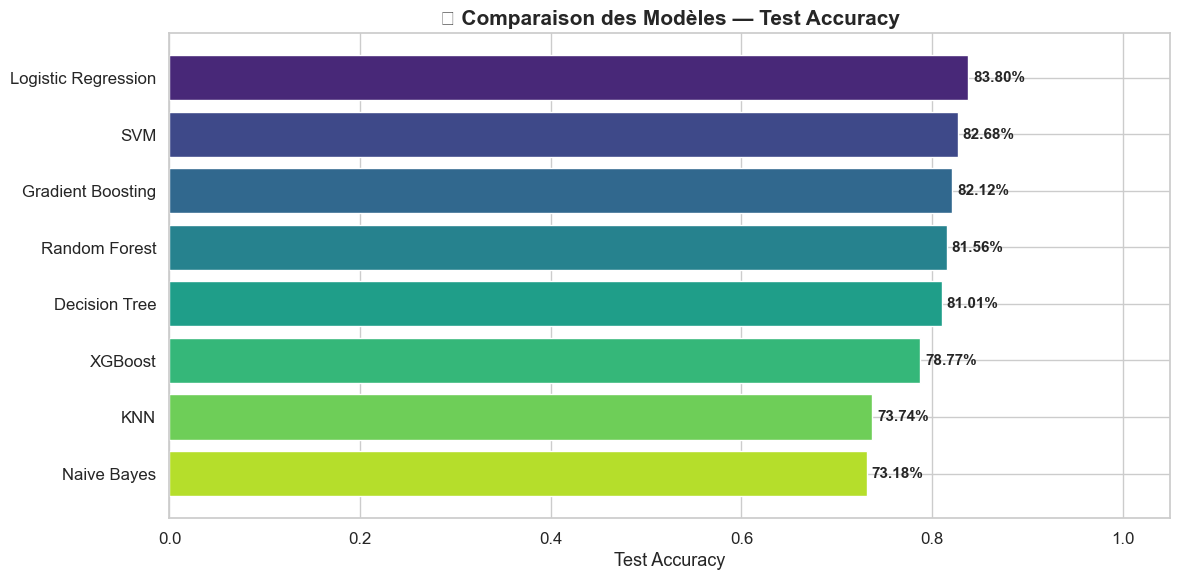

In [23]:
# Visualisation de la comparaison
plot_model_comparison(results_df)

In [24]:
# Rapport détaillé du meilleur modèle
best_name = results_df.index[0]
best_model = trained_models[best_name]

print(f"\n🏆 Meilleur modèle : {best_name}")
print(f"\n📋 Rapport de classification :\n")
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Décédé", "Survécu"]))


🏆 Meilleur modèle : Logistic Regression

📋 Rapport de classification :

              precision    recall  f1-score   support

      Décédé       0.87      0.86      0.87       110
     Survécu       0.79      0.80      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



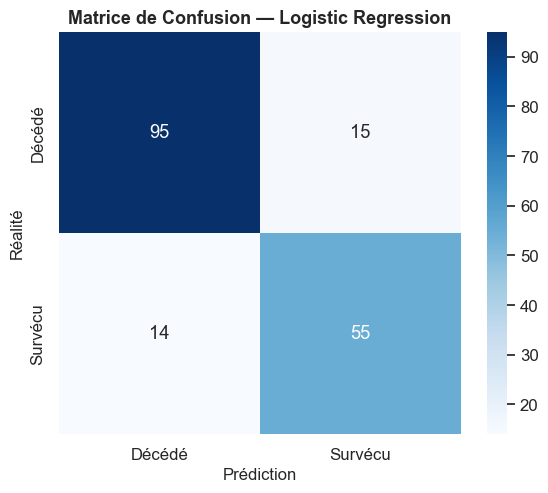

In [25]:
# Matrice de confusion du meilleur modèle
plot_confusion_matrix(best_model, X_test, y_test, name=best_name)

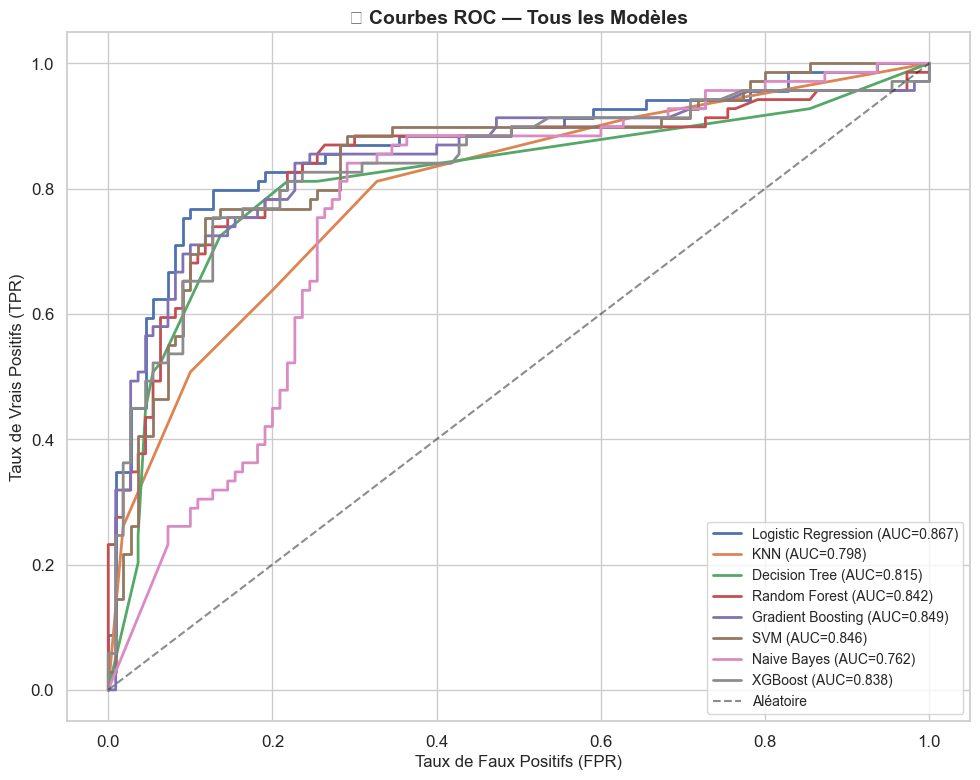

In [26]:
# Courbes ROC de tous les modèles
plot_roc_curves(trained_models, X_test, y_test)

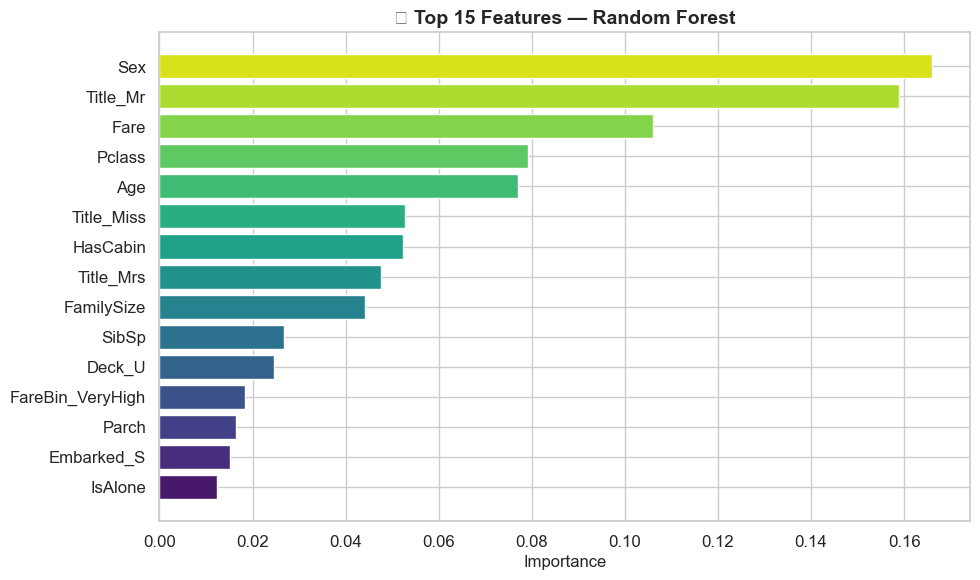

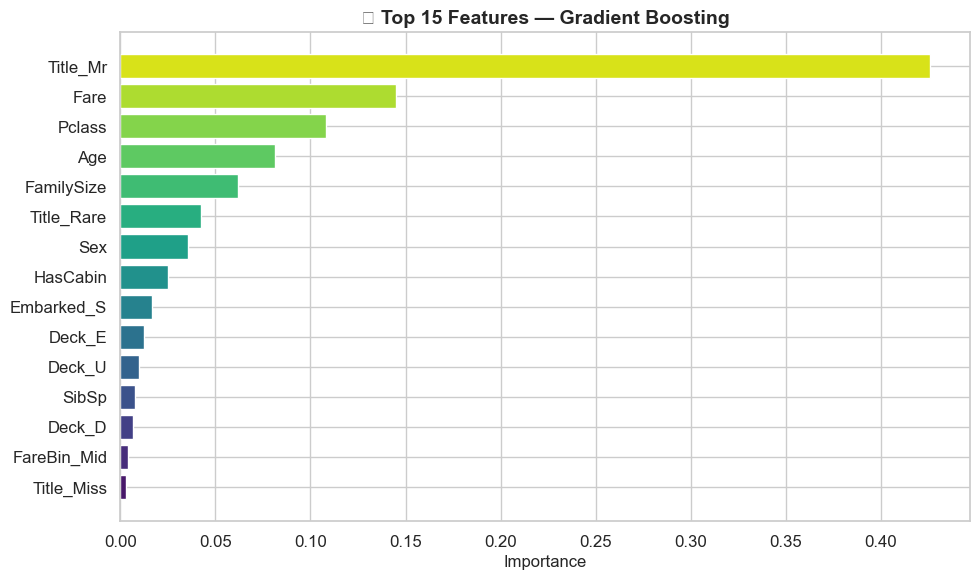

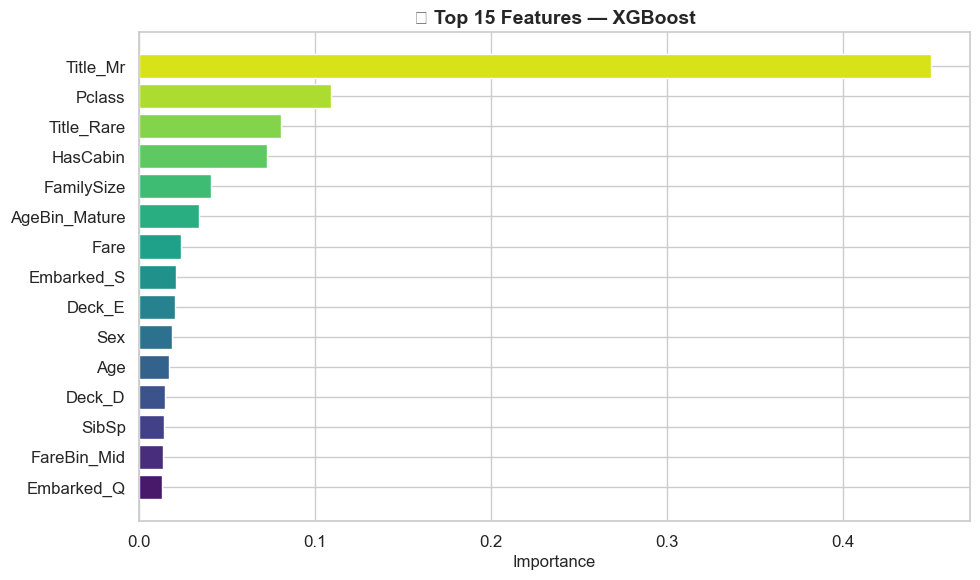

In [27]:
# Feature importance (modèles à base d'arbres)
for name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    if name in trained_models:
        plot_feature_importance(trained_models[name], feature_names, name=name)

---
# ⚠️ Partie 5 — Détection du Sur-apprentissage

**Objectifs :**
- Comparer les performances train vs test
- Identifier l'overfitting
- Solutions : régularisation, cross-validation

In [28]:
# Comparaison Train vs Test (détection overfitting)
print("📊 Analyse du Sur-apprentissage :\n")
print(results_df[["Train Accuracy", "Test Accuracy", "Overfit"]].round(4))

print("\n⚠️ Modèles en sur-apprentissage (écart > 5%) :")
overfit = results_df[results_df["Overfit"] > 0.05]
if len(overfit) > 0:
    for name, row in overfit.iterrows():
        print(f"   ▸ {name}: Train={row['Train Accuracy']:.4f}, Test={row['Test Accuracy']:.4f}, Écart={row['Overfit']:.4f}")
else:
    print("   ✅ Aucun modèle en sur-apprentissage significatif")

📊 Analyse du Sur-apprentissage :

                     Train Accuracy  Test Accuracy  Overfit
Modèle                                                     
Logistic Regression          0.8329         0.8380  -0.0051
SVM                          0.8652         0.8268   0.0384
Gradient Boosting            0.9087         0.8212   0.0875
Random Forest                0.9045         0.8156   0.0889
Decision Tree                0.8666         0.8101   0.0565
XGBoost                      0.9129         0.7877   0.1252
KNN                          0.8652         0.7374   0.1277
Naive Bayes                  0.7346         0.7318   0.0027

⚠️ Modèles en sur-apprentissage (écart > 5%) :
   ▸ Gradient Boosting: Train=0.9087, Test=0.8212, Écart=0.0875
   ▸ Random Forest: Train=0.9045, Test=0.8156, Écart=0.0889
   ▸ Decision Tree: Train=0.8666, Test=0.8101, Écart=0.0565
   ▸ XGBoost: Train=0.9129, Test=0.7877, Écart=0.1252
   ▸ KNN: Train=0.8652, Test=0.7374, Écart=0.1277


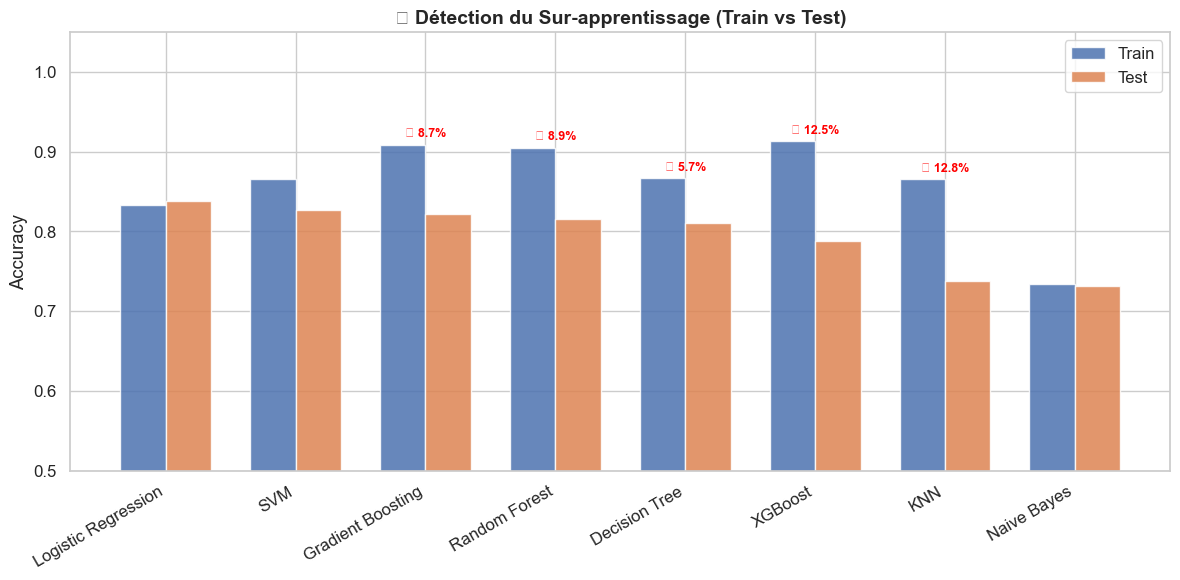

In [29]:
# Diagramme overfitting
plot_overfitting(results_df)

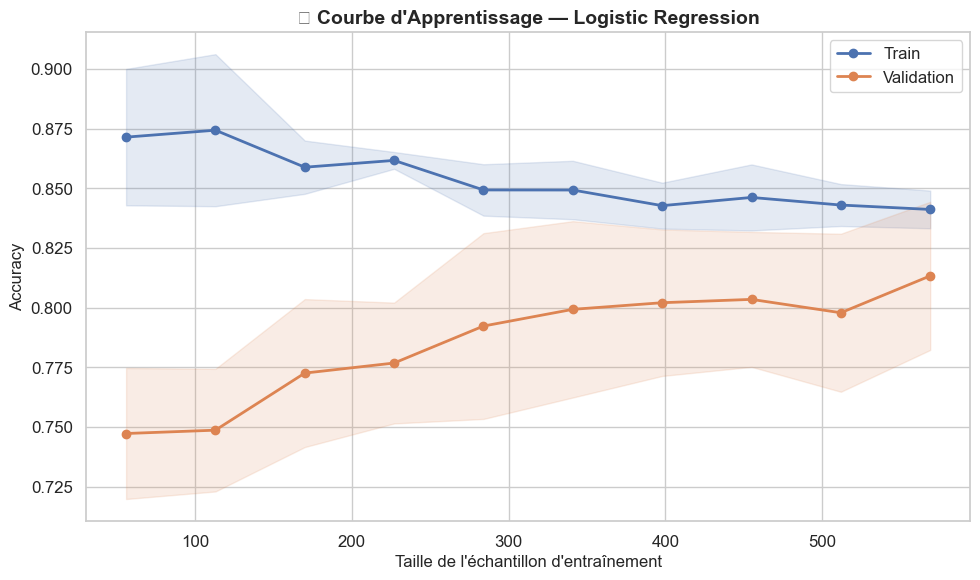

In [30]:
# Courbe d'apprentissage du meilleur modèle
plot_learning_curve(best_model, X_train, y_train, name=best_name)

In [31]:
# Cross-validation (5-fold) pour validation robuste
print("\n📊 Validation Croisée (5-fold) :\n")
cv_results = cross_validate_models(models, X_train, y_train, cv=5)
print("\n" + cv_results.to_string())


📊 Validation Croisée (5-fold) :

   ▸ Logistic Regression: 0.8147 ± 0.0323
   ▸ KNN: 0.8020 ± 0.0193
   ▸ Decision Tree: 0.7936 ± 0.0372
   ▸ Random Forest: 0.8161 ± 0.0258
   ▸ Gradient Boosting: 0.8203 ± 0.0345
   ▸ SVM: 0.8189 ± 0.0262
   ▸ Naive Bayes: 0.7402 ± 0.0557
   ▸ XGBoost: 0.8049 ± 0.0268

                      CV Mean    CV Std        CV Scores
Modèle                                                  
Gradient Boosting    0.820339  0.034507  0.8203 ± 0.0345
SVM                  0.818852  0.026156  0.8189 ± 0.0262
Random Forest        0.816094  0.025803  0.8161 ± 0.0258
Logistic Regression  0.814695  0.032274  0.8147 ± 0.0323
XGBoost              0.804866  0.026831  0.8049 ± 0.0268
KNN                  0.801990  0.019270  0.8020 ± 0.0193
Decision Tree        0.793598  0.037211  0.7936 ± 0.0372
Naive Bayes          0.740195  0.055745  0.7402 ± 0.0557


---
# 🔍 Partie 6 — Optimisation (Grid Search CV)

**Objectifs :**
- Optimiser les hyperparamètres de chaque modèle
- Comparer avant/après optimisation

In [32]:
# Grilles d'hyperparamètres
param_grids = get_param_grids()

# On optimise les 3 meilleurs modèles pour gagner du temps
top_models = list(results_df.index[:3])
print(f"🔍 Optimisation des 3 meilleurs modèles : {top_models}\n")

optimized_models = {}
optimization_results = []

for name in top_models:
    if name in param_grids and name in models:
        print(f"▸ Grid Search sur {name}...")
        grid = GridSearchCV(
            models[name],
            param_grids[name],
            cv=5,
            scoring="accuracy",
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)
        
        before_acc = results_df.loc[name, "Test Accuracy"]
        after_acc = grid.score(X_test, y_test)
        
        optimized_models[name] = grid.best_estimator_
        optimization_results.append({
            "Modèle": name,
            "Avant": before_acc,
            "Après": after_acc,
            "Amélioration": after_acc - before_acc,
            "Meilleurs Params": str(grid.best_params_)
        })
        
        print(f"  ✓ Avant: {before_acc:.4f} → Après: {after_acc:.4f} (Δ={after_acc-before_acc:+.4f})")
        print(f"  Params: {grid.best_params_}\n")

opt_df = pd.DataFrame(optimization_results).set_index("Modèle")
print("\n" + "=" * 60)
print("📊 RÉSUMÉ GRID SEARCH CV")
print("=" * 60)
print(opt_df[["Avant", "Après", "Amélioration"]].round(4).to_string())

🔍 Optimisation des 3 meilleurs modèles : ['Logistic Regression', 'SVM', 'Gradient Boosting']

▸ Grid Search sur Logistic Regression...
  ✓ Avant: 0.8380 → Après: 0.8156 (Δ=-0.0223)
  Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

▸ Grid Search sur SVM...
  ✓ Avant: 0.8268 → Après: 0.7821 (Δ=-0.0447)
  Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

▸ Grid Search sur Gradient Boosting...
  ✓ Avant: 0.8212 → Après: 0.8156 (Δ=-0.0056)
  Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


📊 RÉSUMÉ GRID SEARCH CV
                      Avant   Après  Amélioration
Modèle                                           
Logistic Regression  0.8380  0.8156       -0.0223
SVM                  0.8268  0.7821       -0.0447
Gradient Boosting    0.8212  0.8156       -0.0056


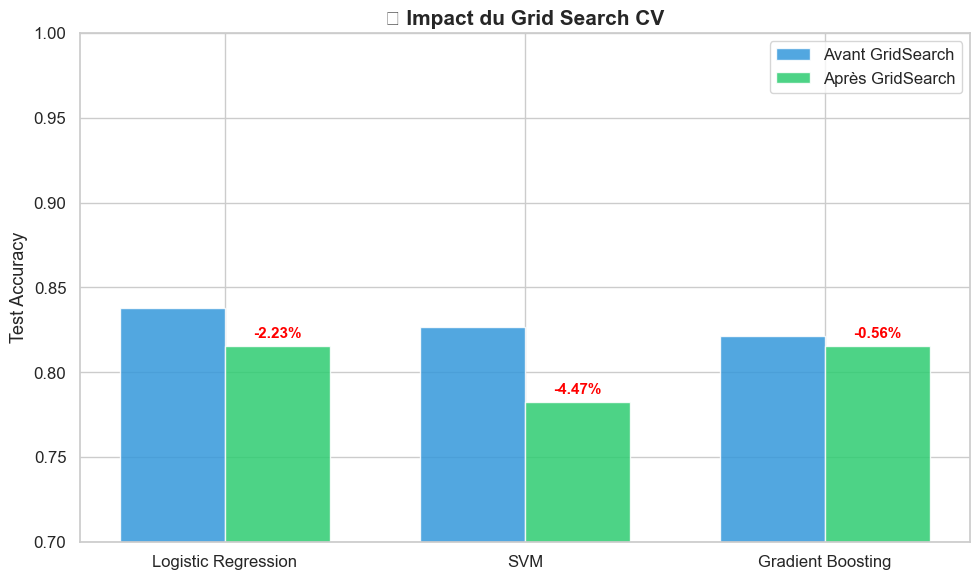

In [33]:
# Visualisation avant/après
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(opt_df))
width = 0.35

ax.bar(x - width/2, opt_df["Avant"], width, label="Avant GridSearch", color="#3498db", alpha=0.85)
ax.bar(x + width/2, opt_df["Après"], width, label="Après GridSearch", color="#2ecc71", alpha=0.85)

for i, (avant, apres) in enumerate(zip(opt_df["Avant"], opt_df["Après"])):
    diff = apres - avant
    color = "green" if diff > 0 else "red"
    ax.annotate(f"{diff:+.2%}", xy=(i + width/2, apres + 0.005), ha="center", fontsize=11, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(opt_df.index, fontsize=12)
ax.set_ylabel("Test Accuracy", fontsize=13)
ax.set_title("🔍 Impact du Grid Search CV", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
ax.set_ylim(0.7, 1.0)
plt.tight_layout()
plt.savefig("../reports/figures/gridsearch_comparison.png", bbox_inches="tight")
plt.show()

---
# 🧩 Partie 7 — Ensemble Learning

**Méthodes :**
- Bagging
- Boosting (AdaBoost)
- Voting (Hard & Soft)
- Stacking

In [34]:
# Charger les modèles d'ensemble
ensemble_models = get_ensemble_models()

print(f"📦 {len(ensemble_models)} modèles d'ensemble :")
for name in ensemble_models:
    print(f"   ▸ {name}")

📦 5 modèles d'ensemble :
   ▸ Voting (Soft)
   ▸ Voting (Hard)
   ▸ Bagging
   ▸ Stacking
   ▸ AdaBoost


In [35]:
# Entraîner et comparer les ensembles
print("\n🚀 Entraînement des modèles d'ensemble...\n")
ensemble_results_df, ensemble_trained = compare_models(
    ensemble_models, X_train, X_test, y_train, y_test
)


🚀 Entraînement des modèles d'ensemble...

   ▸ Entraînement de Voting (Soft)... ✓ Accuracy: 0.8156
   ▸ Entraînement de Voting (Hard)... ✓ Accuracy: 0.8212
   ▸ Entraînement de Bagging... ✓ Accuracy: 0.8324
   ▸ Entraînement de Stacking... ✓ Accuracy: 0.8156
   ▸ Entraînement de AdaBoost... ✓ Accuracy: 0.8268

📊 COMPARAISON DES MODÈLES
               Train Accuracy  Test Accuracy  Precision  Recall  F1-Score  AUC-ROC  Overfit
Modèle                                                                                     
Bagging                0.9284         0.8324     0.8095  0.7391    0.7727   0.8555   0.0960
AdaBoost               0.8525         0.8268     0.7794  0.7681    0.7737   0.8580   0.0257
Voting (Hard)          0.8975         0.8212     0.7846  0.7391    0.7612      NaN   0.0762
Voting (Soft)          0.9073         0.8156     0.7903  0.7101    0.7481   0.8605   0.0917
Stacking               0.9115         0.8156     0.7903  0.7101    0.7481   0.8549   0.0959


In [36]:
# Comparaison ensembles vs modèles individuels
all_results = pd.concat([results_df, ensemble_results_df])
all_results = all_results.sort_values("Test Accuracy", ascending=False)

print("\n" + "=" * 70)
print("🏆 CLASSEMENT GLOBAL (Individuels + Ensembles)")
print("=" * 70)
print(all_results[["Test Accuracy", "F1-Score", "AUC-ROC"]].round(4).to_string())


🏆 CLASSEMENT GLOBAL (Individuels + Ensembles)
                     Test Accuracy  F1-Score  AUC-ROC
Modèle                                               
Logistic Regression         0.8380    0.7914   0.8669
Bagging                     0.8324    0.7727   0.8555
SVM                         0.8268    0.7737   0.8456
AdaBoost                    0.8268    0.7737   0.8580
Gradient Boosting           0.8212    0.7538   0.8489
Voting (Hard)               0.8212    0.7612      NaN
Random Forest               0.8156    0.7481   0.8425
Stacking                    0.8156    0.7481   0.8549
Voting (Soft)               0.8156    0.7481   0.8605
Decision Tree               0.8101    0.7463   0.8155
XGBoost                     0.7877    0.7031   0.8385
KNN                         0.7374    0.6519   0.7976
Naive Bayes                 0.7318    0.7176   0.7622


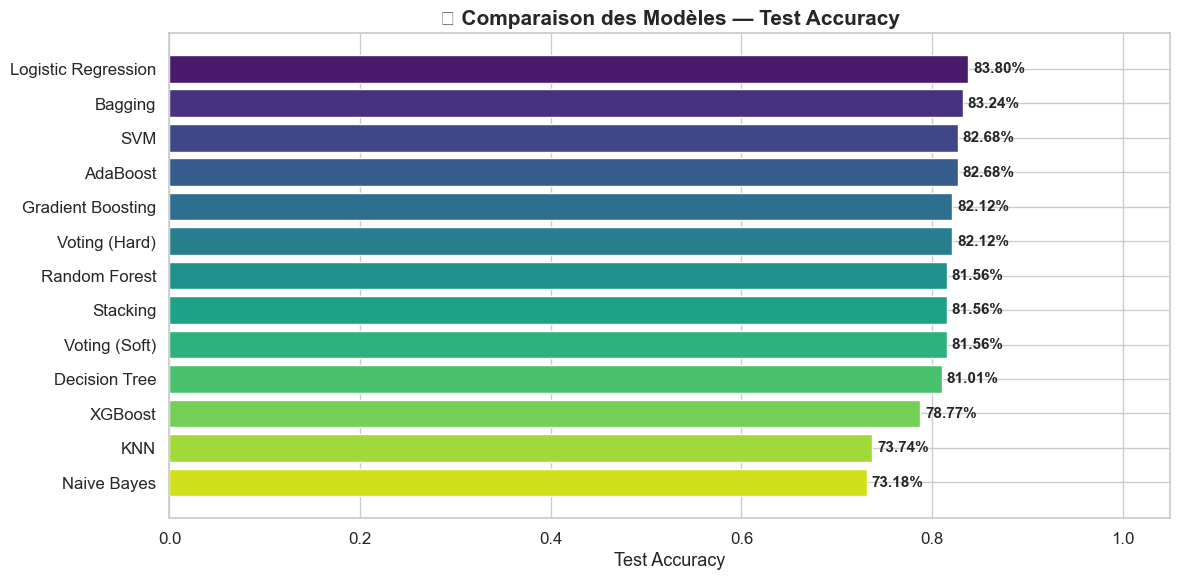

In [37]:
# Visualisation du classement global
plot_model_comparison(all_results)

---
# 🚀 Partie 8 — Introduction au MLOps

**Objectifs :**
1. Versioning du modèle
2. Pipeline de données automatisée (a lire response.md )
3. Déploiement via API (FastAPI) : 
4. Monitoring & réentraînement (partie admin)

---

### 8.1 — Versioning du Modèle

In [38]:
# Sauvegarder le meilleur modèle
# On prend le meilleur du classement global
global_best_name = all_results.index[0]

# Vérifier si c'est un modèle optimisé ou original
if global_best_name in optimized_models:
    final_model = optimized_models[global_best_name]
elif global_best_name in trained_models:
    final_model = trained_models[global_best_name]
elif global_best_name in ensemble_trained:
    final_model = ensemble_trained[global_best_name]
else:
    final_model = best_model

print(f"🏆 Meilleur modèle global : {global_best_name}")
print(f"   Test Accuracy : {all_results.loc[global_best_name, 'Test Accuracy']:.4f}")
print(f"   F1-Score      : {all_results.loc[global_best_name, 'F1-Score']:.4f}")

# Sauvegarde avec joblib (versioning)
model_path = save_best_model(final_model, scaler, feature_names, "../models/best_model.pkl")
print(f"\n📦 Modèle sauvegardé : {model_path}")

🏆 Meilleur modèle global : Logistic Regression
   Test Accuracy : 0.8380
   F1-Score      : 0.7914
✅ Modèle sauvegardé → models/best_model.pkl (Latest)
✅ Version archivée → models/best_model_20260418_151616.pkl

📦 Modèle sauvegardé : models/best_model.pkl


In [39]:
# Test de l'API (simulation locale)
from src.preprocessing import full_preprocessing, load_data
import joblib

# Charger le modèle sauvegardé
artifact = joblib.load("../models/best_model.pkl")
print(f"📦 Modèle chargé : {artifact['model_name']}")
print(f"   Features : {len(artifact['feature_names'])}")
print(f"\n✅ Le modèle est prêt pour le déploiement !")
print(f"\n🚀 Pour lancer l'API :")
print(f"   cd .. && uvicorn api.app:app --reload")

FileNotFoundError: [Errno 2] No such file or directory: '../models/best_model.pkl'